In [145]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [143]:

# Data Collection and Processing
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('../data/heart_disease_data.csv')

In [125]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [126]:

# number of rows and columns in the dataset
print(f"\nDataset shape: {heart_data.shape}")


Dataset shape: (303, 14)


In [127]:
# getting some info about the data
print("\nDataset info:")
heart_data.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [128]:

# checking for missing values
print("\nMissing values:")
print(heart_data.isnull().sum())


Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [130]:
# statistical measures about the data
print("\nStatistical summary:")
heart_data.describe()


Statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [131]:
# checking the distribution of Target Variable
print("\nTarget distribution:")
heart_data['target'].value_counts()


Target distribution:


target
1    165
0    138
Name: count, dtype: int64

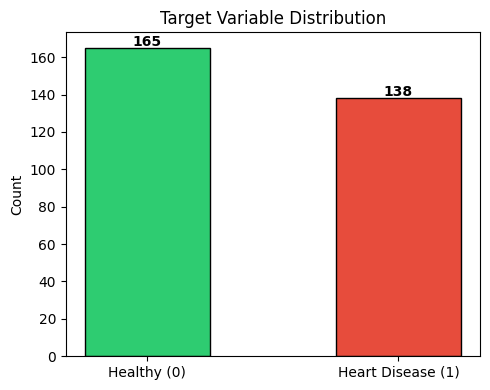

In [132]:
# 1 --> Defective Heart
# 0 --> Healthy Heart

# Data Visualization
# 1. Target Distribution
target_counts = heart_data['target'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(['Healthy (0)', 'Heart Disease (1)'], target_counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


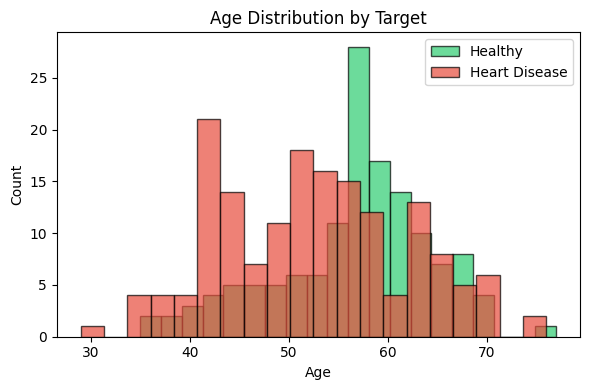

In [133]:

# 2. Age Distribution by Target
plt.figure(figsize=(6, 4))
plt.hist(heart_data[heart_data['target']==0]['age'], bins=20,
         alpha=0.7, color='#2ecc71', label='Healthy', edgecolor='black')
plt.hist(heart_data[heart_data['target']==1]['age'], bins=20,
         alpha=0.7, color='#e74c3c', label='Heart Disease', edgecolor='black')
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 500x400 with 0 Axes>

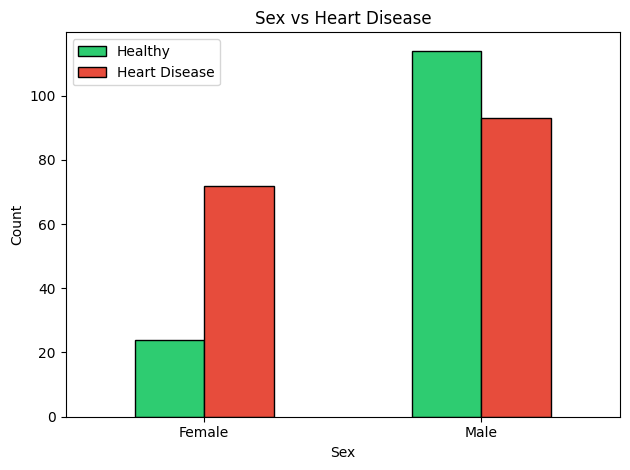

In [134]:
# 3. Sex vs Heart Disease
plt.figure(figsize=(5, 4))
sex_target = heart_data.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                edgecolor='black', width=0.5)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.ylabel('Count')
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

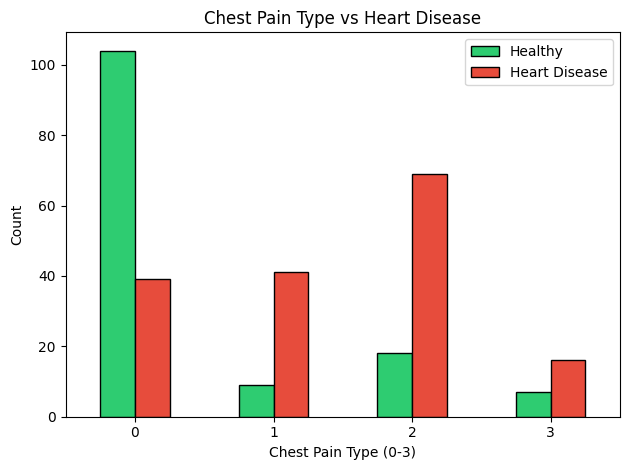

In [135]:
# 4. Chest Pain Type vs Heart Disease
plt.figure(figsize=(6, 4))
cp_target = heart_data.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.5)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

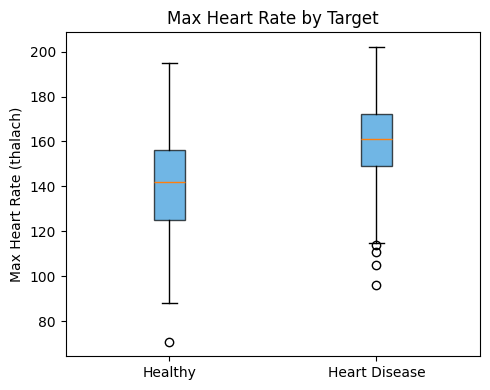

In [136]:
# 5. Max Heart Rate by Target
plt.figure(figsize=(5, 4))
data_to_plot = [heart_data[heart_data['target']==0]['thalach'],
                heart_data[heart_data['target']==1]['thalach']]
plt.boxplot(data_to_plot, labels=['Healthy', 'Heart Disease'],
            patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Max Heart Rate by Target')
plt.ylabel('Max Heart Rate (thalach)')
plt.tight_layout()
plt.show()


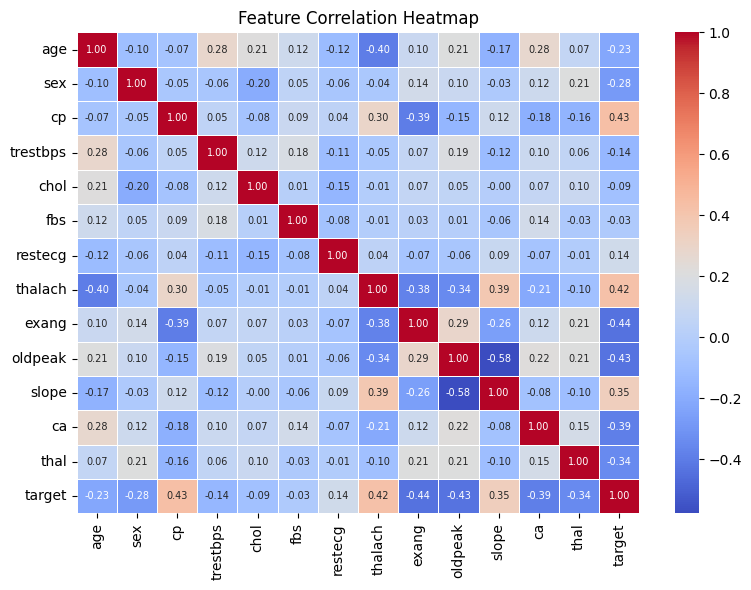

In [137]:
# 6. Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = heart_data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [144]:
# Splitting Features and Target
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [146]:
# Feature Encoding & Scaling
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")



Training set shape: (242, 30)
Test set shape: (61, 30)


In [156]:
# XGBoost Model with Regularization 
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.6, 0.7],
    'reg_alpha': [0.1, 0.5],  # L1 regularization
    'reg_lambda': [0.5, 1.0]  # L2 regularization
}
print("\nPerforming Grid Search...")
model = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1
)

grid_search.fit(X_train, Y_train)

best_params = grid_search.best_params_
print(f"\n✅ Best Parameters: {best_params}")

# Train final model
final_model = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=15
)
final_model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)

# Predictions
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

# Accuracies
train_acc = accuracy_score(train_pred, Y_train)
test_acc = accuracy_score(test_pred, Y_test)

print(f"\n Training Accuracy: {train_acc:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")


Performing Grid Search...
Fitting 5 folds for each of 64 candidates, totalling 320 fits

✅ Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.6}

 Training Accuracy: 0.8926
 Test Accuracy: 0.8197



 Training Accuracy: 0.8926
 Test Accuracy: 0.8197


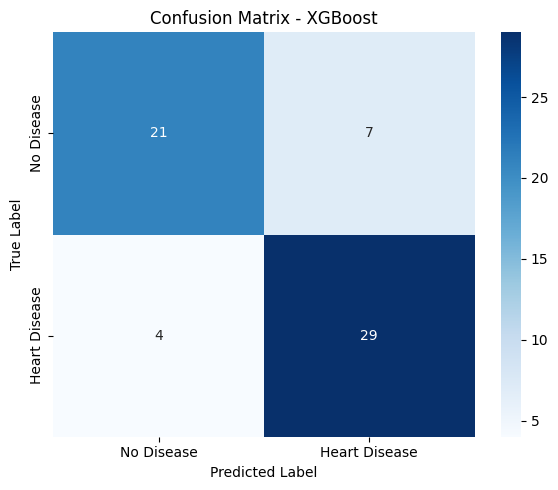


📋 Classification Report:

               precision    recall  f1-score   support

   No Disease       0.84      0.75      0.79        28
Heart Disease       0.81      0.88      0.84        33

     accuracy                           0.82        61
    macro avg       0.82      0.81      0.82        61
 weighted avg       0.82      0.82      0.82        61



In [152]:
# Confusion Matrix
cm = confusion_matrix(Y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()

print('\n📋 Classification Report:\n')
print(classification_report(Y_test, test_pred, target_names=['No Disease', 'Heart Disease']))